# **Image Query System - Moteur de Recherche Visuel**

## **_Phase 1_***: Acquisition et préparation des données*

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from torchvision import transforms


## 1. Chargement des données

In [ ]:
# Chemin 
DATA_DIR  = r"../data/clothing-dataset"

# Chemin trainset
TRAIN_DIR = os.path.join(DATA_DIR, "train")
# Chemin testset
TEST_DIR  = os.path.join(DATA_DIR, "test")

## 2. Analyse Exploratoire (EDA)
### 2.1 Distribution des classes

Nombre de classes : 10
Total images train : 3068

 dress : 241 images
 hat : 123 images
 longsleeve : 455 images
 outwear : 184 images
 pants : 468 images
 shirt : 290 images
 shoes : 198 images
 shorts : 202 images
 skirt : 112 images
 t-shirt : 795 images


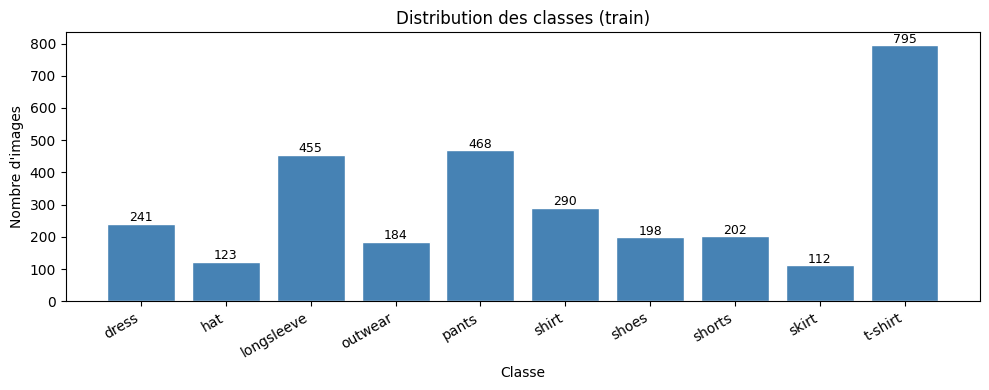

In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

print(f"Nombre de classes : {len(classes)}")
print(f"Total images train : {sum(counts)}\n")

for cls, n in zip(classes, counts):
    print(f" {cls} : {n} images")

# Visualisation de la distribution
plt.figure(figsize=(10, 4))
bars = plt.bar(classes, counts, color="steelblue", edgecolor="white")
plt.title("Distribution des classes (train)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=30, ha="right")

for bar, n in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(n), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../results/distribution_classes.png", dpi=150)
plt.show()

### 2.2 Tailles des images

Largeur -- min: 400, max: 888, moy: 425
Hauteur -- min: 400, max: 936, moy: 517
Images analysées : 3068


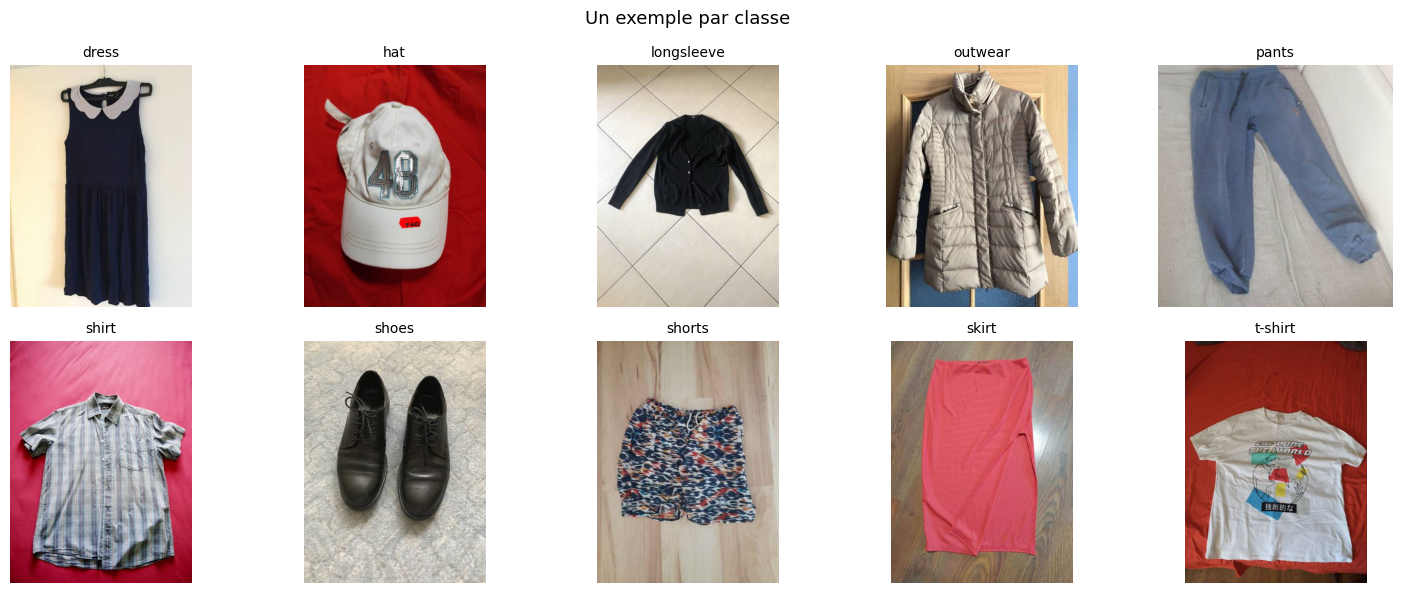

In [ ]:
widths, heights = [], []

for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        try:
            w, h = Image.open(os.path.join(cls_dir, fname)).size
            widths.append(w)
            heights.append(h)
        except:
            pass

print(f"Largeur -- min: {min(widths)}, max: {max(widths)}, moy: {int(np.mean(widths))}")
print(f"Hauteur -- min: {min(heights)}, max: {max(heights)}, moy: {int(np.mean(heights))}")
print(f"Images analysées : {len(widths)}")

# Exemples visuels par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Un exemple par classe", fontsize=13)

for ax, cls in zip(axes.flat, classes):
    img_path = os.path.join(TRAIN_DIR, cls,
                os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    ax.imshow(Image.open(img_path))
    ax.set_title(cls, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/exemples_classes.png", dpi=150)
plt.show()

## 3. Nettoyage 

In [26]:
# Détection des fichiers corrompus
corrompus = []

for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            img = Image.open(fpath)
            img.verify()  # vérifie l'intégrité sans charger en mémoire
        except Exception as e:
            corrompus.append((fpath, str(e)))

print(f"Fichiers corrompus détectés : {len(corrompus)}")
for path, err in corrompus:
    print(f"  {path} -> {err}")

Fichiers corrompus détectés : 0


## 4. Vérification du split train / validation / test

In [35]:
VAL_DIR = os.path.join(DATA_DIR, "validation")

splits = {"train": TRAIN_DIR, "validation": VAL_DIR, "test": TEST_DIR}

print(f"{'Classe'} -   {'Train'} - {'Val'} - {'Test'} - {'Total'}")


for cls in classes:
    counts_split = []
    for split, d in splits.items():
        cls_dir = os.path.join(d, cls)
        n = len(os.listdir(cls_dir)) if os.path.exists(cls_dir) else 0
        counts_split.append(n)
    total = sum(counts_split)
    print(f"{cls} -  {counts_split[0]} - {counts_split[1]} - {counts_split[2]} - {total}")


totaux = []
for split, d in splits.items():
    t = sum(len(os.listdir(os.path.join(d, c)))
            for c in classes if os.path.exists(os.path.join(d, c)))
    totaux.append(t)
print(f"{'TOTAL'} -   {totaux[0]} - {totaux[1]} - {totaux[2]} - {sum(totaux)}")

Classe -   Train - Val - Test - Total
dress -  241 - 32 - 15 - 288
hat -  123 - 14 - 12 - 149
longsleeve -  455 - 49 - 72 - 576
outwear -  184 - 24 - 38 - 246
pants -  468 - 49 - 42 - 559
shirt -  290 - 29 - 26 - 345
shoes -  198 - 26 - 73 - 297
shorts -  202 - 25 - 30 - 257
skirt -  112 - 12 - 12 - 136
t-shirt -  795 - 81 - 52 - 928
TOTAL -   3068 - 341 - 372 - 3781


## 5. Construction de la liste d'indexation

In [42]:
def build_image_list(root_dir, classes):
    records = []
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            records.append({
                "path"  : os.path.join(cls_dir, fname),
                "label" : cls
            })
    return pd.DataFrame(records)

df_train = build_image_list(TRAIN_DIR, classes)
df_val = build_image_list(VAL_DIR, classes)
df_test = build_image_list(TEST_DIR, classes)

print(f"Train : {len(df_train)} images")
print(f"Val : {len(df_val)} images")
print(f"Test : {len(df_test)} images")
print(f"\nAperçu :")
print(df_train.head())


# Sauvegarde des listes d'images
df_train.to_csv("../results/train_list.csv", index=False)
df_val.to_csv("../results/val_list.csv", index=False)
df_test.to_csv("../results/test_list.csv", index=False)

print()
print("Listes sauvegardées dans results/")

Train : 3068 images
Val : 341 images
Test : 372 images

Aperçu :
                                                path  label
0  ../data/clothing-dataset\train\dress\009b3c31-...  dress
1  ../data/clothing-dataset\train\dress\041c6bde-...  dress
2  ../data/clothing-dataset\train\dress\04f0b07f-...  dress
3  ../data/clothing-dataset\train\dress\053689bb-...  dress
4  ../data/clothing-dataset\train\dress\0546d34a-...  dress

Listes sauvegardées dans results/


## 6. Preprocessing : redimensionnement uniforme (224x224), normalisation des pixels

Taille originale : (400, 533)
Taille après resize : torch.Size([3, 224, 224])
Min pixel : -1.930
Max pixel : 2.605


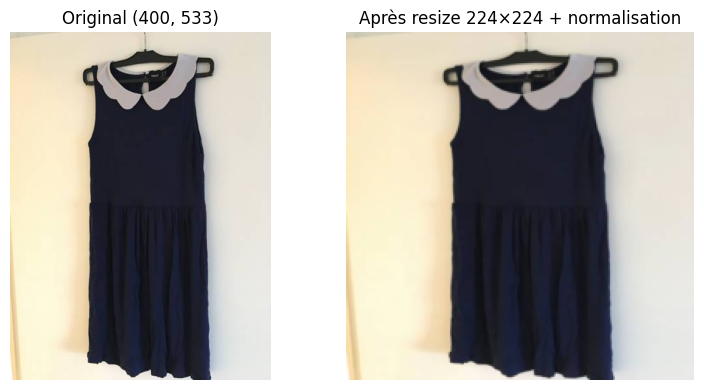

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Vérification sur un échantillon
sample_path = df_train.iloc[0]["path"]
img_pil = Image.open(sample_path).convert("RGB")
img_tensor  = transform(img_pil)

print(f"Taille originale : {img_pil.size}")
print(f"Taille après resize : {img_tensor.shape}")
print(f"Min pixel : {img_tensor.min():.3f}")
print(f"Max pixel : {img_tensor.max():.3f}")


# Visualisation avant / après
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_pil)
axes[0].set_title(f"Original {img_pil.size}")
axes[0].axis("off")

# Dénormalisation pour affichage
img_display = img_tensor.permute(1, 2, 0).numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

axes[1].imshow(img_display)
axes[1].set_title("Après resize 224×224 + normalisation")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../results/preprocessing_exemple.png", dpi=150)
plt.show()